# latihan



=== 5 Data Pertama ===
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121 



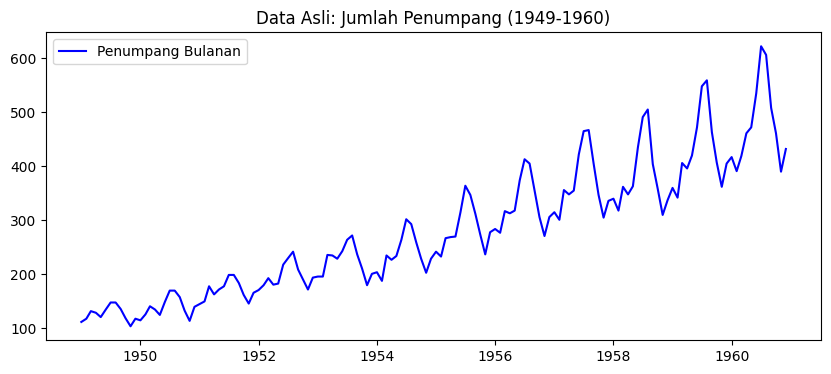

=== Hasil Uji Augmented Dickey-Fuller (ADF) ===
P-Value: 0.99188
Kesimpulan: Data NON-STASIONER (Gagal tolak H0). Perlu Differencing!



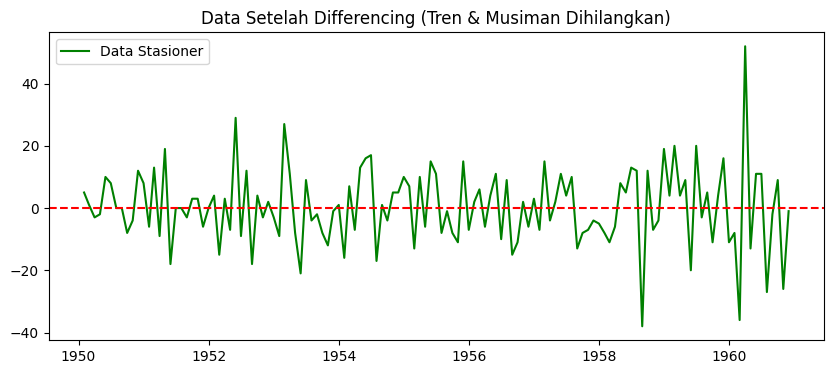

Cek ADF Test setelah differencing:
=== Hasil Uji Augmented Dickey-Fuller (ADF) ===
P-Value: 0.00000
Kesimpulan: Data sudah STASIONER (Tolak H0).

Jumlah Data Latih (Train): 132
Jumlah Data Uji (Test): 12

Sedang mencari model ARIMA terbaik secara otomatis...

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=2.20 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1022.234, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=906.857, Time=0.39 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=963.555, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1192.711, Time=0.03 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=907.180, Time=0.12 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=908.543, Time=1.19 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=1.16 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=907.120, Time=0.42 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=5.03 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1021

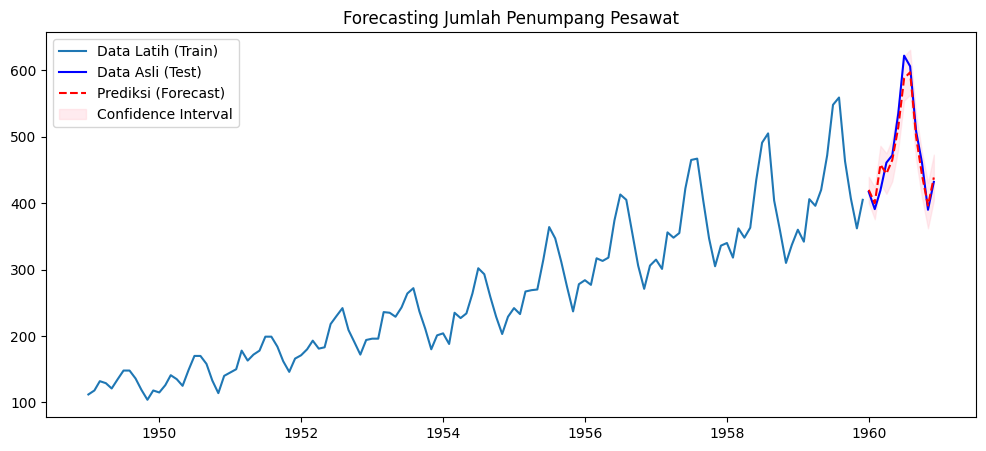

In [5]:
#!pip install pmdarima
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------------------------------------------------------
# 1. LOAD DATA (Menggunakan dataset bawaan untuk kemudahan)
# ---------------------------------------------------------
# Di Colab, kita ambil data AirPassengers dari github raw
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

print("=== 5 Data Pertama ===")
print(df.head(), "\n")

# Plot Data Asli
plt.figure(figsize=(10,4))
plt.plot(df.index, df['Passengers'], label='Penumpang Bulanan', color='blue')
plt.title('Data Asli: Jumlah Penumpang (1949-1960)')
plt.legend()
plt.show()


# ---------------------------------------------------------
# 2. CEK STASIONERITAS DENGAN ADF TEST
# ---------------------------------------------------------
def cek_stasioner(timeseries):
    print("=== Hasil Uji Augmented Dickey-Fuller (ADF) ===")
    hasil_adf = adfuller(timeseries, autolag='AIC')
    p_value = hasil_adf[1]

    print(f'P-Value: {p_value:.5f}')
    if p_value <= 0.05:
        print("Kesimpulan: Data sudah STASIONER (Tolak H0).\n")
    else:
        print("Kesimpulan: Data NON-STASIONER (Gagal tolak H0). Perlu Differencing!\n")

# Cek data asli kita
cek_stasioner(df['Passengers'])


# ---------------------------------------------------------
# 3. TRANSFORMASI: MENGATASI NON-STASIONER
# ---------------------------------------------------------
# Karena data punya tren dan musiman, kita lakukan 2 tahap differencing

# Tahap A: Differencing Biasa (lag 1) untuk menghilangkan Tren
df['diff_1'] = df['Passengers'].diff(periods=1)

# Tahap B: Differencing Musiman (lag 12) untuk menghilangkan Musiman tahunan
# Kita diff dari diff_1, dengan periode 12 bulan
df['diff_seasonal'] = df['diff_1'].diff(periods=12)

# Hapus baris yang kosong (NaN) akibat differencing
data_stasioner = df['diff_seasonal'].dropna()

# Plot data setelah ditransformasi
plt.figure(figsize=(10,4))
plt.plot(data_stasioner.index, data_stasioner, label='Data Stasioner', color='green')
plt.title('Data Setelah Differencing (Tren & Musiman Dihilangkan)')
plt.axhline(0, color='red', linestyle='--')
plt.legend()
plt.show()

# Cek lagi apakah sekarang sudah stasioner
print("Cek ADF Test setelah differencing:")
cek_stasioner(data_stasioner)


# ---------------------------------------------------------
# 4. SPLIT DATA: TRAIN vs TEST
# ---------------------------------------------------------
# Kita tidak boleh potong acak! Kita potong berdasarkan waktu.
# Total data 144 bulan. Kita ambil 132 bulan (11 tahun) untuk Train, 12 bulan (1 tahun) terakhir untuk Test.
train_size = len(df) - 12
train = df['Passengers'].iloc[:train_size]
test = df['Passengers'].iloc[train_size:]

print(f"Jumlah Data Latih (Train): {len(train)}")
print(f"Jumlah Data Uji (Test): {len(test)}\n")


# ---------------------------------------------------------
# 5. MODELING MENGGUNAKAN AUTO-ARIMA
# ---------------------------------------------------------
print("Sedang mencari model ARIMA terbaik secara otomatis...\n")
# Kita berikan data Train (asli). Auto-ARIMA pintar, dia akan melakukan differencing (d)
# secara internal jika kita beritahu ada musiman (m=12).
model = auto_arima(train,
                   seasonal=True, # Aktifkan SARIMA (karena ada musiman)
                   m=12,          # Siklus musiman adalah 12 (bulanan)
                   trace=True,    # Tampilkan proses pencariannya
                   error_action='ignore',
                   suppress_warnings=True,
                   stepwise=True)

print("\n=== Ringkasan Model Terbaik ===")
print(model.summary())


# ---------------------------------------------------------
# 6. EVALUASI (PREDIKSI PADA DATA TEST)
# ---------------------------------------------------------
# Prediksi sebanyak jumlah data Test (12 bulan)
prediksi, conf_int = model.predict(n_periods=len(test), return_conf_int=True)
prediksi.index = test.index # Samakan index waktunya

# Hitung Error
mae = mean_absolute_error(test, prediksi)
rmse = np.sqrt(mean_squared_error(test, prediksi))
print(f"\n=== Evaluasi Error ===")
print(f"MAE  (Rata-rata Meleset): {mae:.2f} penumpang")
print(f"RMSE (Penalti Error Besar): {rmse:.2f} penumpang\n")


# ---------------------------------------------------------
# 7. VISUALISASI HASIL PREDIKSI vs DATA ASLI
# ---------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Data Latih (Train)')
plt.plot(test.index, test, label='Data Asli (Test)', color='blue')
plt.plot(prediksi.index, prediksi, label='Prediksi (Forecast)', color='red', linestyle='--')

# Membuat bayangan rentang kepercayaan (Confidence Interval)
lower_bound = conf_int[:, 0]
upper_bound = conf_int[:, 1]
plt.fill_between(prediksi.index, lower_bound, upper_bound, color='pink', alpha=0.3, label='Confidence Interval')

plt.title('Forecasting Jumlah Penumpang Pesawat')
plt.legend(loc='upper left')
plt.show()

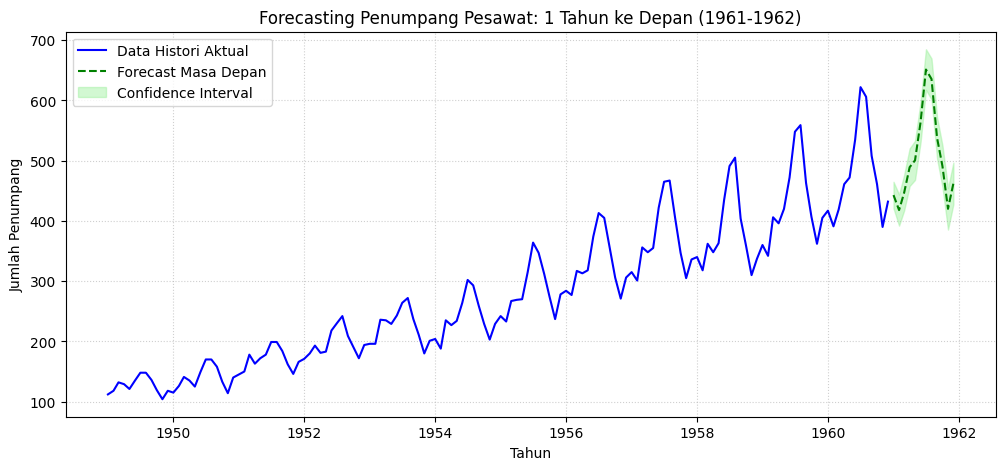


=== Nilai Prediksi 6 Bulan Pertama di Masa Depan ===
1961-01-01    443.0
1961-02-01    418.0
1961-03-01    446.0
1961-04-01    489.0
1961-05-01    501.0
1961-06-01    564.0
Freq: MS, dtype: float64


In [6]:
# 8. FORECASTING MASA DEPAN (BEYOND THE DATASET)
# Latih ulang model menggunakan 100% data historis yang kita punya
model.fit(df['Passengers'])

# Tentukan berapa bulan ke depan yang ingin diprediksi (misal: 24 bulan / 2 tahun)
langkah_ke_depan = 12
forecast_masa_depan, conf_int_masa_depan = model.predict(n_periods=langkah_ke_depan, return_conf_int=True)

# Membuat index tanggal untuk masa depan
# Data terakhir kita adalah 1960-12-01. Kita buat urutan bulan setelahnya.
tanggal_terakhir = df.index[-1]
index_masa_depan = pd.date_range(start=tanggal_terakhir + pd.DateOffset(months=1),
                                 periods=langkah_ke_depan,
                                 freq='MS') # MS = Month Start

forecast_masa_depan.index = index_masa_depan

# --- VISUALISASI MASA DEPAN ---
plt.figure(figsize=(12, 5))

# 1. Plot seluruh data histori (1949 - 1960)
plt.plot(df.index, df['Passengers'], label='Data Histori Aktual', color='blue')

# 2. Plot garis prediksi masa depan (1961 - 1962)
plt.plot(forecast_masa_depan.index, forecast_masa_depan, label='Forecast Masa Depan', color='green', linestyle='--')

# 3. Buat bayangan batas atas dan bawah (Confidence Interval)
lower_bound_future = conf_int_masa_depan[:, 0]
upper_bound_future = conf_int_masa_depan[:, 1]
plt.fill_between(forecast_masa_depan.index,
                 lower_bound_future,
                 upper_bound_future,
                 color='lightgreen', alpha=0.4, label='Confidence Interval')

# Percantik grafik
plt.title('Forecasting Penumpang Pesawat: 1 Tahun ke Depan (1961-1962)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Penumpang')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("\n=== Nilai Prediksi 6 Bulan Pertama di Masa Depan ===")
print(round(forecast_masa_depan.head(6)))